# Zeroshot Error Analysis for Selecting Fewshot Examples

This notebook aggregates false positives (FP) and false negatives (FN) across
**all zeroshot model runs** (8 models × 2 languages × 3 temperatures = 48 runs)
to find the best candidates for fewshot examples.

**Method:** We rank errors by **cross-model consensus** — the more models that
make the same mistake, the more likely it is a genuinely hard case rather than
a model-specific quirk. This way the selected fewshot examples are
model-agnostic and represent the hardest cases for any model.

- **False Negatives (FN):** gold entities that many models missed
  → good "here's what you should have found" examples
- **False Positives (FP):** hallucinated entities that many models predicted
  → good "here's what NOT to predict" examples

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
print("Imports loaded")

Imports loaded


In [32]:
ERRORS_DIR = Path.cwd().parent / "ner" / "ner-evaluation" / "errors_logs"
if not ERRORS_DIR.exists():
    ERRORS_DIR = Path.cwd() / "ner-evaluation" / "errors_logs"

error_files = sorted(ERRORS_DIR.glob("*_zeroshot_*_errors.csv"))
print(f"Found {len(error_files)} zeroshot error files")

def parse_filename(filename: str):
    """Extract model, temperature, language from filename."""
    stem = Path(filename).stem.removesuffix("_errors")
    # Pattern: <letter>__<model>_t<temp>_zeroshot_<lang>
    m = re.search(r"__([^_].+?)_t([\d.]+)_zeroshot_([a-z]+)$", stem)
    if m:
        return m.group(1), float(m.group(2)), m.group(3)
    return stem, None, None

frames = []
for fp in error_files:
    model, temp, lang = parse_filename(fp.name)
    df = pd.read_csv(fp)
    df["model"] = model
    df["temperature"] = temp
    df["language"] = lang
    frames.append(df)

all_errors = pd.concat(frames, ignore_index=True)
print(f"Total error rows: {len(all_errors)}")
print(f"Models: {all_errors['model'].nunique()}")
print(f"Languages: {sorted(all_errors['language'].unique())}")
print(f"Temperatures: {sorted(all_errors['temperature'].unique())}")
all_errors.head(3)

Found 48 zeroshot error files
Total error rows: 18472
Models: 8
Languages: ['dutch', 'english']
Temperatures: [0.0, 0.5, 1.0]


,type,label,page,gold_text,pred_text,gold_start,gold_end,pred_start,pred_end,model,temperature,language
0,FN,F2_Expression,16,\nDerde Brief,NaN,4.0,16.0,NaN,NaN,cogito-2.1:671b,0.0,dutch
1,FN,E52_Time_Span,16,eene halve dag,NaN,99.0,113.0,NaN,NaN,cogito-2.1:671b,0.0,dutch
2,FN,Mode_of_Transportation,16,ryden,NaN,145.0,150.0,NaN,NaN,cogito-2.1:671b,0.0,dutch


## 2. Overview: Error distribution

How many FN and FP across all runs, per model and per label.

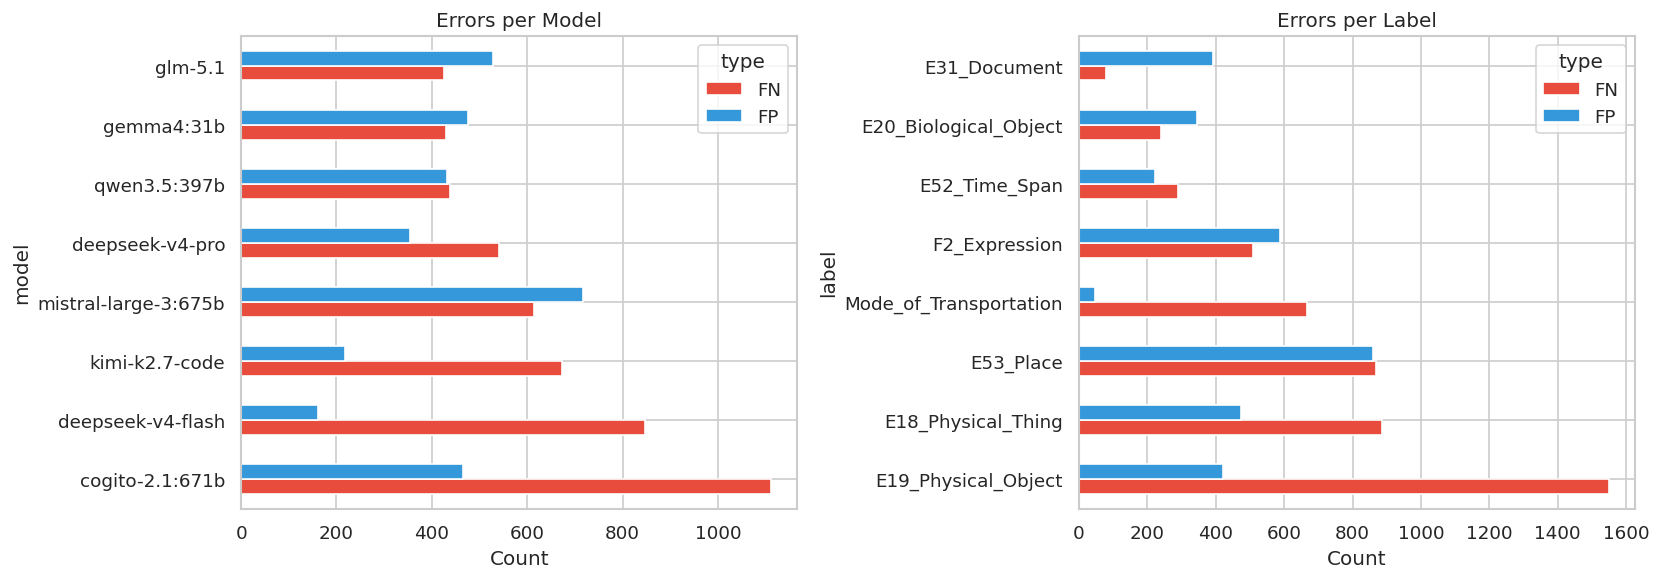

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per model
pivot_model = all_errors.pivot_table(
    index="model", columns="type", aggfunc="size", fill_value=0
)
pivot_model = pivot_model.sort_values("FN", ascending=False)
pivot_model[["FN", "FP"]].plot(kind="barh", ax=axes[0], color={"FN": "#E74C3C", "FP": "#3498DB"})
axes[0].set_title("Errors per Model")
axes[0].set_xlabel("Count")

# Per label
pivot_label = all_errors.pivot_table(
    index="label", columns="type", aggfunc="size", fill_value=0
)
pivot_label = pivot_label.sort_values("FN", ascending=False)
pivot_label[["FN", "FP"]].plot(kind="barh", ax=axes[1], color={"FN": "#E74C3C", "FP": "#3498DB"})
axes[1].set_title("Errors per Label")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

## 3. Cross-model consensus: False Negatives

For each gold entity, count how many model runs missed it.
Higher = more models failed → better fewshot candidate.

In [34]:
fn_only = all_errors[all_errors["type"] == "FN"].copy()

# Group by (label, page, gold_text) — count how many model runs missed it
fn_consensus = (
    fn_only.groupby(["label", "page", "gold_text"], dropna=False)
    .agg(
        n_missed=("model", "nunique"),
        total_attempts=("model", "count"),
        models=("model", lambda x: ", ".join(sorted(x.unique()))),
    )
    .reset_index()
)

total_runs = all_errors["model"].nunique()
fn_consensus["miss_rate"] = fn_consensus["n_missed"] / total_runs
fn_consensus = fn_consensus.sort_values("n_missed", ascending=False)

print(f"Unique gold entities missed: {len(fn_consensus)}")
print(f"Total model runs: {total_runs}")
print(f"\nTop 20 most-missed entities (best fewshot FN candidates):")
fn_consensus.head(20)

Unique gold entities missed: 264
Total model runs: 8

Top 20 most-missed entities (best fewshot FN candidates):


,label,page,gold_text,n_missed,total_attempts,models,miss_rate
195,E53_Place,22,2 verdiepingen,8,39,"cogito-2.1:671b, deepseek-v4-flash, deepseek-v...",1.0
231,F2_Expression,22,"een postillon die, hoe men zich ook plaatste, ...",8,48,"cogito-2.1:671b, deepseek-v4-flash, deepseek-v...",1.0
89,E19_Physical_Object,22,een klein strandgezicht,8,48,"cogito-2.1:671b, deepseek-v4-flash, deepseek-v...",1.0
84,E19_Physical_Object,21,19 landgraven & landgravinnen,8,35,"cogito-2.1:671b, deepseek-v4-flash, deepseek-v...",1.0
229,F2_Expression,21,het 2de deel van de door de Heeren Tydeman & v...,8,47,"cogito-2.1:671b, deepseek-v4-flash, deepseek-v...",1.0
228,F2_Expression,19,"de brieven voornoemd 1 deel bl 167, 168, 169",8,48,"cogito-2.1:671b, deepseek-v4-flash, deepseek-v...",1.0
82,E19_Physical_Object,20,twee worstelaars,8,37,"cogito-2.1:671b, deepseek-v4-flash, deepseek-v...",1.0
39,E18_Physical_Thing,23,logement,8,34,"cogito-2.1:671b, deepseek-v4-flash, deepseek-v...",1.0
226,F2_Expression,16,\nDerde Brief,8,48,"cogito-2.1:671b, deepseek-v4-flash, deepseek-v...",1.0
224,E53_Place,25,dubbele linden allee,8,41,"cogito-2.1:671b, deepseek-v4-flash, deepseek-v...",1.0


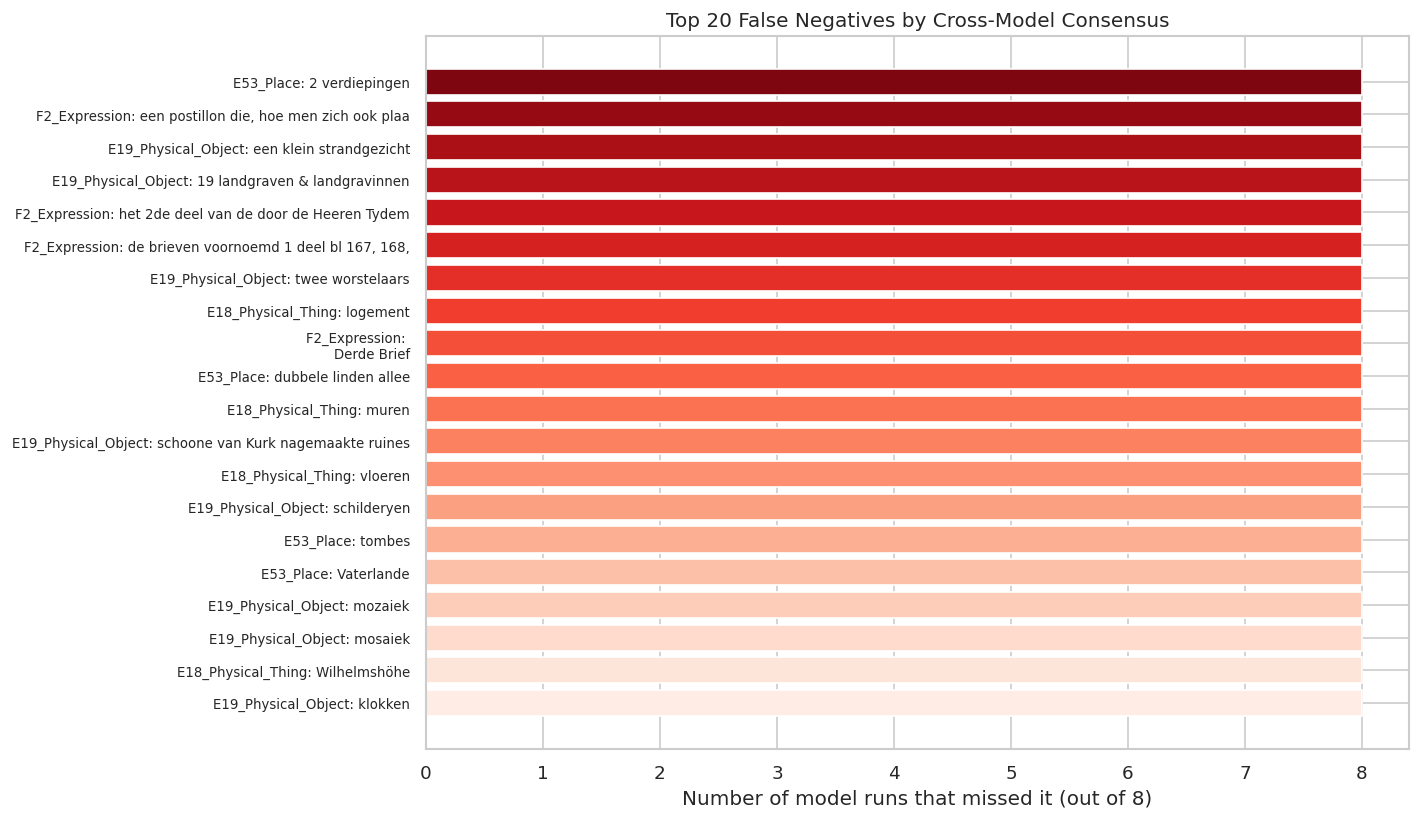

In [35]:
# Bar chart: top 20 FN by consensus
top_fn = fn_consensus.head(20).copy()
top_fn["label_text"] = top_fn["label"] + ": " + top_fn["gold_text"].str[:40]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(
    range(len(top_fn)),
    top_fn["n_missed"],
    color=sns.color_palette("Reds_r", len(top_fn)),
    edgecolor="white",
)
ax.set_yticks(range(len(top_fn)))
ax.set_yticklabels(top_fn["label_text"], fontsize=8)
ax.set_xlabel(f"Number of model runs that missed it (out of {total_runs})")
ax.set_title("Top 20 False Negatives by Cross-Model Consensus")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Cross-model consensus: False Positives

For each hallucinated entity, count how many model runs predicted it.
Higher = more models hallucinated → good "what NOT to do" example.

In [36]:
fp_only = all_errors[all_errors["type"] == "FP"].copy()

fp_consensus = (
    fp_only.groupby(["label", "page", "pred_text"], dropna=False)
    .agg(
        n_hallucinated=("model", "nunique"),
        total_attempts=("model", "count"),
        models=("model", lambda x: ", ".join(sorted(x.unique()))),
    )
    .reset_index()
)

fp_consensus["hallu_rate"] = fp_consensus["n_hallucinated"] / total_runs
fp_consensus = fp_consensus.sort_values("n_hallucinated", ascending=False)

print(f"Unique hallucinated entities: {len(fp_consensus)}")
print(f"\nTop 20 most-hallucinated entities (best fewshot FP candidates):")
fp_consensus.head(20)

Unique hallucinated entities: 627

Top 20 most-hallucinated entities (best fewshot FP candidates):


,label,page,pred_text,n_hallucinated,total_attempts,models,hallu_rate
329,E31_Document,24,eerste deel,8,21,"cogito-2.1:671b, deepseek-v4-flash, deepseek-v...",1.000
284,E31_Document,16,Derde Brief,8,39,"cogito-2.1:671b, deepseek-v4-flash, deepseek-v...",1.000
568,F2_Expression,22,Cleopatra,8,35,"cogito-2.1:671b, deepseek-v4-flash, deepseek-v...",1.000
85,E18_Physical_Thing,23,trappen,8,14,"cogito-2.1:671b, deepseek-v4-flash, deepseek-v...",1.000
304,E31_Document,21,alphabetische,8,36,"cogito-2.1:671b, deepseek-v4-flash, deepseek-v...",1.000
303,E31_Document,21,Mnemosyne,8,42,"cogito-2.1:671b, deepseek-v4-flash, deepseek-v...",1.000
321,E31_Document,23,reizen van Profr van Swinderen,8,30,"cogito-2.1:671b, deepseek-v4-flash, deepseek-v...",1.000
459,E53_Place,21,Cassels,8,48,"cogito-2.1:671b, deepseek-v4-flash, deepseek-v...",1.000
98,E18_Physical_Thing,24,tombes,8,40,"cogito-2.1:671b, deepseek-v4-flash, deepseek-v...",1.000
508,E53_Place,24,Cassels,8,34,"cogito-2.1:671b, deepseek-v4-flash, deepseek-v...",1.000


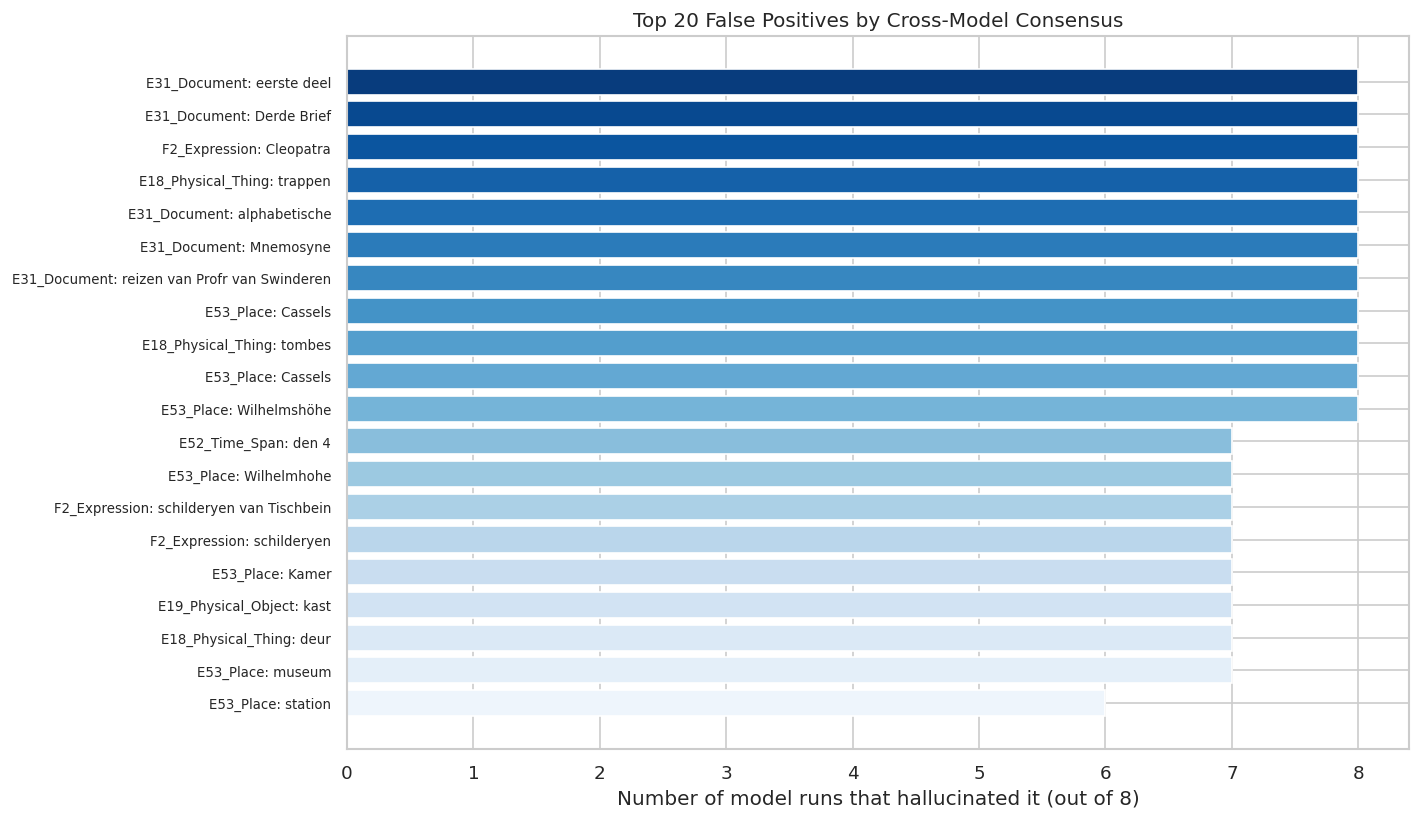

In [37]:
# Bar chart: top 20 FP by consensus
top_fp = fp_consensus.head(20).copy()
top_fp["label_text"] = top_fp["label"] + ": " + top_fp["pred_text"].str[:40]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(
    range(len(top_fp)),
    top_fp["n_hallucinated"],
    color=sns.color_palette("Blues_r", len(top_fp)),
    edgecolor="white",
)
ax.set_yticks(range(len(top_fp)))
ax.set_yticklabels(top_fp["label_text"], fontsize=8)
ax.set_xlabel(f"Number of model runs that hallucinated it (out of {total_runs})")
ax.set_title("Top 20 False Positives by Cross-Model Consensus")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Per-label consensus distribution

Which labels have the most cross-model errors? Helps decide how many
fewshot examples to allocate per label.

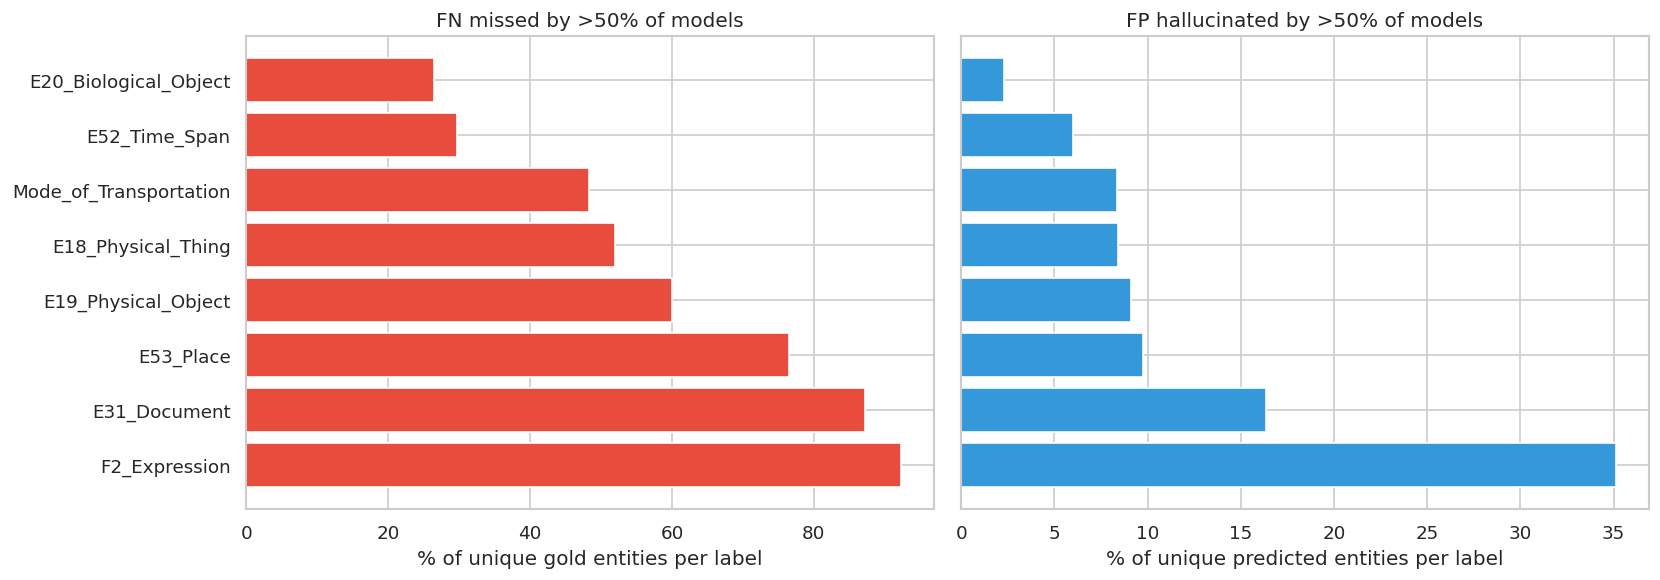

In [38]:
# Total unique entities per label (denominator for normalisation)
total_fn_per_label = fn_consensus.groupby("label").size()
total_fp_per_label = fp_consensus.groupby("label").size()

# FN per label: fraction of entities missed by >50% of models
fn_by_label_raw = fn_consensus[fn_consensus["miss_rate"] > 0.5].groupby("label").size()
fn_by_label = (fn_by_label_raw / total_fn_per_label * 100).dropna().sort_values(ascending=False)

# FP per label: fraction of entities hallucinated by >50% of models
fp_by_label_raw = fp_consensus[fp_consensus["hallu_rate"] > 0.5].groupby("label").size()
fp_by_label = (fp_by_label_raw / total_fp_per_label * 100).dropna().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].barh(range(len(fn_by_label)), fn_by_label.values, color="#E74C3C", edgecolor="white")
axes[0].set_yticks(range(len(fn_by_label)))
axes[0].set_yticklabels(fn_by_label.index)
axes[0].set_title("FN missed by >50% of models")
axes[0].set_xlabel("% of unique gold entities per label")

axes[1].barh(range(len(fp_by_label)), fp_by_label.values, color="#3498DB", edgecolor="white")
axes[1].set_yticks(range(len(fp_by_label)))
axes[1].set_yticklabels(fp_by_label.index)
axes[1].set_title("FP hallucinated by >50% of models")
axes[1].set_xlabel("% of unique predicted entities per label")

plt.tight_layout()
plt.show()

## 6. Recommended fewshot examples

The table below shows the best candidates for fewshot examples, ranked by
cross-model consensus. Pick from the top of each list to cover the hardest
cases that all models struggle with.

In [39]:
# --- FN candidates ("here's what you missed") ---
fn_candidates = fn_consensus.head(30)[["label", "page", "gold_text", "n_missed", "miss_rate"]].copy()
fn_candidates.columns = ["Label", "Page", "Entity Text", "Models Missed", "Miss Rate"]
fn_candidates["Type"] = "FN (missed)"

# --- FP candidates ("here's what NOT to predict") ---
fp_candidates = fp_consensus.head(30)[["label", "page", "pred_text", "n_hallucinated", "hallu_rate"]].copy()
fp_candidates.columns = ["Label", "Page", "Entity Text", "Models Missed", "Miss Rate"]
fp_candidates["Type"] = "FP (hallucinated)"

# Combine and show
candidates = pd.concat([fn_candidates, fp_candidates], ignore_index=True)
candidates["Miss Rate"] = candidates["Miss Rate"].round(2)
candidates = candidates.sort_values(["Type", "Models Missed"], ascending=[True, False])
candidates

,Label,Page,Entity Text,Models Missed,Miss Rate,Type
0,E53_Place,22,2 verdiepingen,8,1.00,FN (missed)
1,F2_Expression,22,"een postillon die, hoe men zich ook plaatste, ...",8,1.00,FN (missed)
2,E19_Physical_Object,22,een klein strandgezicht,8,1.00,FN (missed)
3,E19_Physical_Object,21,19 landgraven & landgravinnen,8,1.00,FN (missed)
4,F2_Expression,21,het 2de deel van de door de Heeren Tydeman & v...,8,1.00,FN (missed)
5,F2_Expression,19,"de brieven voornoemd 1 deel bl 167, 168, 169",8,1.00,FN (missed)
6,E19_Physical_Object,20,twee worstelaars,8,1.00,FN (missed)
7,E18_Physical_Thing,23,logement,8,1.00,FN (missed)
8,F2_Expression,16,\nDerde Brief,8,1.00,FN (missed)
9,E53_Place,25,dubbele linden allee,8,1.00,FN (missed)


## 7. Summary statistics

In [40]:
print("=== ZEROSHOT ERROR ANALYSIS SUMMARY ===")
print(f"Model runs analysed: {all_errors['model'].nunique()}")
print(f"Total error rows: {len(all_errors)}")
print(f"  False Negatives: {(all_errors['type'] == 'FN').sum()}")
print(f"  False Positives: {(all_errors['type'] == 'FP').sum()}")
print()
print(f"Unique gold entities missed (FN): {fn_only['gold_text'].nunique()}")
print(f"Unique hallucinated entities (FP): {fp_only['pred_text'].nunique()}")
print()
print(f"FN missed by ALL {total_runs} runs: {(fn_consensus['n_missed'] == total_runs).sum()}")
print(f"FP hallucinated by ALL {total_runs} runs: {(fp_consensus['n_hallucinated'] == total_runs).sum()}")

=== ZEROSHOT ERROR ANALYSIS SUMMARY ===
Model runs analysed: 8
Total error rows: 18472
  False Negatives: 5084
  False Positives: 3352

Unique gold entities missed (FN): 245
Unique hallucinated entities (FP): 475

FN missed by ALL 8 runs: 51
FP hallucinated by ALL 8 runs: 11


## 8. Consistent Mislabelings (Label Confusions)

Entities where models **detect the correct span** but assign the **wrong label**.
These are the most interesting errors: the model sees the entity but disagrees
with the ground truth about its type.

**How we detect them:** An FP row (predicted span with label A) and an FN row
(gold span with label B) that share the same page and have **overlapping spans**
→ the model found the right text but labeled it wrong.

Grouped by `(gs_label → pred_label, entity_text)` and ranked by how many
models consistently make the same label confusion.</cell_id>
<｜DSML｜parameter name="cell_id" string="true">cell-16

In [41]:
# ── Build mislabeling pairs ──────────────────────────────────────────────
# Match FP and FN rows that share the same page and overlapping spans.
# An FP row means the model predicted label A for span S.
# An FN row means the GS says span S has label B.
# Together: the model found the right entity but assigned the wrong label.

def spans_overlap(a_start, a_end, b_start, b_end):
    """True if two character-offset spans overlap."""
    return a_start < b_end and b_start < a_end


fp_only = all_errors[all_errors["type"] == "FP"].copy()
fn_only = all_errors[all_errors["type"] == "FN"].copy()

# Build lookup: page → list of (gold_text, gold_start, gold_end, gs_label, model)
# We match on (page, model_run) to count per-model consensus later.
mislabel_pairs = []

for (page, model_run), fp_group in fp_only.groupby(["page", "model"]):
    fn_for_page_model = fn_only[
        (fn_only["page"] == page) & (fn_only["model"] == model_run)
    ]
    if len(fn_for_page_model) == 0:
        continue
    
    for _, fp_row in fp_group.iterrows():
        ps, pe = int(fp_row["pred_start"]), int(fp_row["pred_end"])
        for _, fn_row in fn_for_page_model.iterrows():
            gs, ge = int(fn_row["gold_start"]), int(fn_row["gold_end"])
            if spans_overlap(ps, pe, gs, ge):
                mislabel_pairs.append({
                    "model": model_run,
                    "page": page,
                    "entity_text": fp_row["pred_text"],
                    "gs_label": fn_row["label"],      # what GS says
                    "pred_label": fp_row["label"],    # what model predicted
                    "gs_start": gs,
                    "gs_end": ge,
                    "pred_start": ps,
                    "pred_end": pe,
                })

mislabel_df = pd.DataFrame(mislabel_pairs)
print(f"Total mislabeling instances (model-run level): {len(mislabel_df)}")
print(f"Unique entity texts involved: {mislabel_df['entity_text'].nunique()}")
print(f"Unique (gs_label → pred_label) pairs: {mislabel_df.groupby(['gs_label','pred_label']).ngroups}")

Total mislabeling instances (model-run level): 7027
Unique entity texts involved: 191
Unique (gs_label → pred_label) pairs: 31


In [42]:
# ── Aggregate by (gs_label, pred_label, entity_text) ────────────────────
# Count how many distinct models make each label confusion on each entity.

mislabel_consensus = (
    mislabel_df.groupby(["gs_label", "pred_label", "entity_text", "page"])
    .agg(
        n_models=("model", "nunique"),
        n_instances=("model", "count"),
        models=("model", lambda x: ", ".join(sorted(x.unique()))),
    )
    .reset_index()
)

total_models = all_errors["model"].nunique()
mislabel_consensus["model_rate"] = mislabel_consensus["n_models"] / total_models
mislabel_consensus = mislabel_consensus.sort_values(
    ["n_models", "gs_label", "entity_text"], ascending=[False, True, True]
)

# Label the confusion direction
mislabel_consensus["confusion"] = (
    mislabel_consensus["gs_label"] + " → " + mislabel_consensus["pred_label"]
)

print(f"Unique mislabeling patterns: {len(mislabel_consensus)}")
print(f"Mislabeled by ALL {total_models} models: {(mislabel_consensus['n_models'] == total_models).sum()}")
print(f"Mislabeled by ≥{total_models//2} models: {(mislabel_consensus['n_models'] >= total_models//2).sum()}")
print()
print("=== All consistent mislabelings (≥50% of models) ===")
display(mislabel_consensus[mislabel_consensus["n_models"] >= total_models//2]
    [["entity_text", "page", "confusion", "n_models", "model_rate", "models"]]
    .rename(columns={"n_models": "# models", "model_rate": "rate"})
    .reset_index(drop=True))

Unique mislabeling patterns: 246
Mislabeled by ALL 8 models: 8
Mislabeled by ≥4 models: 46

=== All consistent mislabelings (≥50% of models) ===


,entity_text,page,confusion,# models,rate,models
0,Wilhelmshöhe,25,E18_Physical_Thing → E53_Place,8,1.000,"cogito-2.1:671b, deepseek-v4-flash, deepseek-v..."
1,Cleopatra,22,E19_Physical_Object → F2_Expression,8,1.000,"cogito-2.1:671b, deepseek-v4-flash, deepseek-v..."
2,tombes,24,E53_Place → E18_Physical_Thing,8,1.000,"cogito-2.1:671b, deepseek-v4-flash, deepseek-v..."
3,Cassels,24,F2_Expression → E53_Place,8,1.000,"cogito-2.1:671b, deepseek-v4-flash, deepseek-v..."
4,Derde Brief,16,F2_Expression → E31_Document,8,1.000,"cogito-2.1:671b, deepseek-v4-flash, deepseek-v..."
5,Mnemosyne,21,F2_Expression → E31_Document,8,1.000,"cogito-2.1:671b, deepseek-v4-flash, deepseek-v..."
6,eerste deel,24,F2_Expression → E31_Document,8,1.000,"cogito-2.1:671b, deepseek-v4-flash, deepseek-v..."
7,reizen van Profr van Swinderen,23,F2_Expression → E31_Document,8,1.000,"cogito-2.1:671b, deepseek-v4-flash, deepseek-v..."
8,Wilhelmhohe,18,E18_Physical_Thing → E53_Place,7,0.875,"deepseek-v4-flash, deepseek-v4-pro, gemma4:31b..."
9,museum,21,E18_Physical_Thing → E53_Place,7,0.875,"cogito-2.1:671b, deepseek-v4-pro, gemma4:31b, ..."


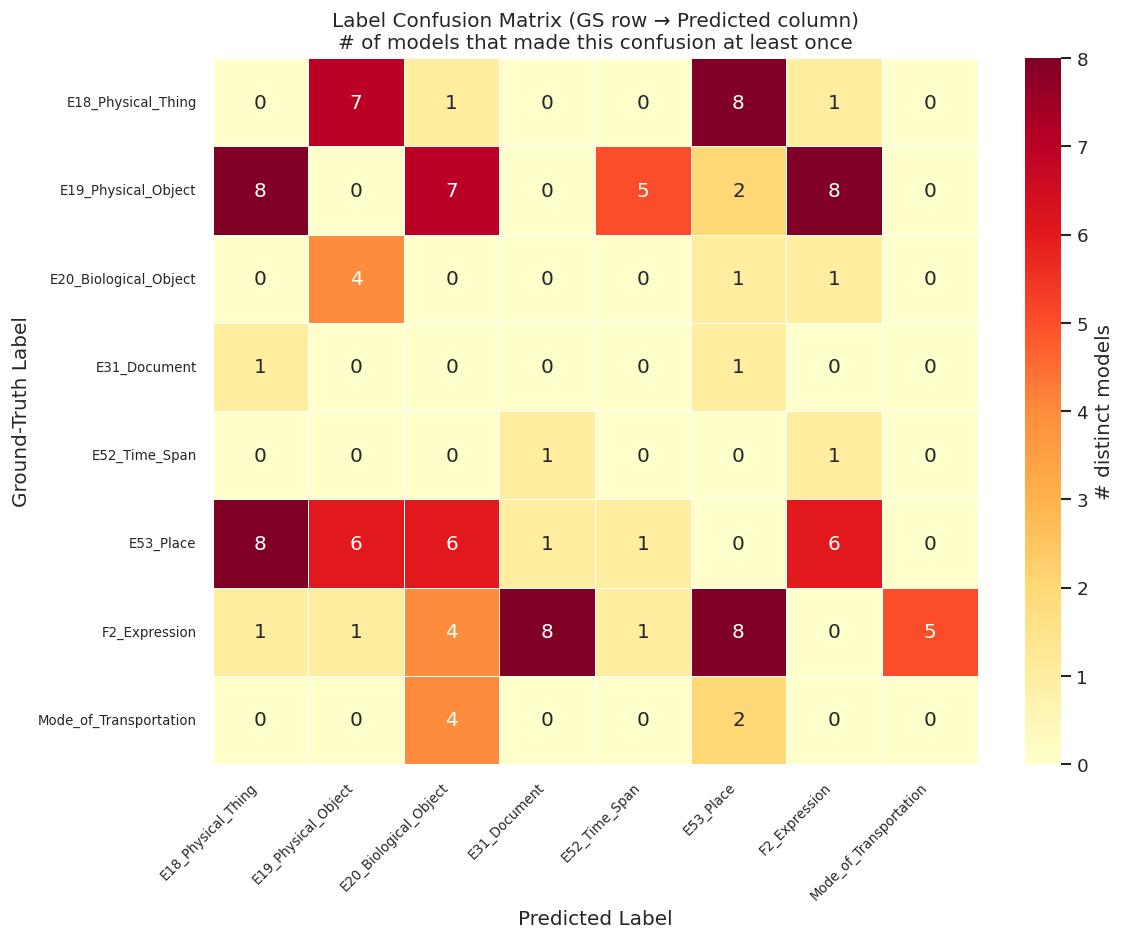

In [43]:
# ── Heatmap: label confusion matrix ──────────────────────────────────────
# Shows which label pairs are most often confused.

confusion_matrix = (
    mislabel_df.groupby(["gs_label", "pred_label"])
    .agg(n_models=("model", "nunique"))
    .reset_index()
    .pivot(index="gs_label", columns="pred_label", values="n_models")
    .fillna(0)
    .astype(int)
)

# Keep only labels that actually appear
all_labels = sorted(set(confusion_matrix.index) | set(confusion_matrix.columns))
confusion_matrix = confusion_matrix.reindex(index=all_labels, columns=all_labels, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    confusion_matrix,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "# distinct models"},
)
ax.set_title("Label Confusion Matrix (GS row → Predicted column)\n# of models that made this confusion at least once")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Ground-Truth Label")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

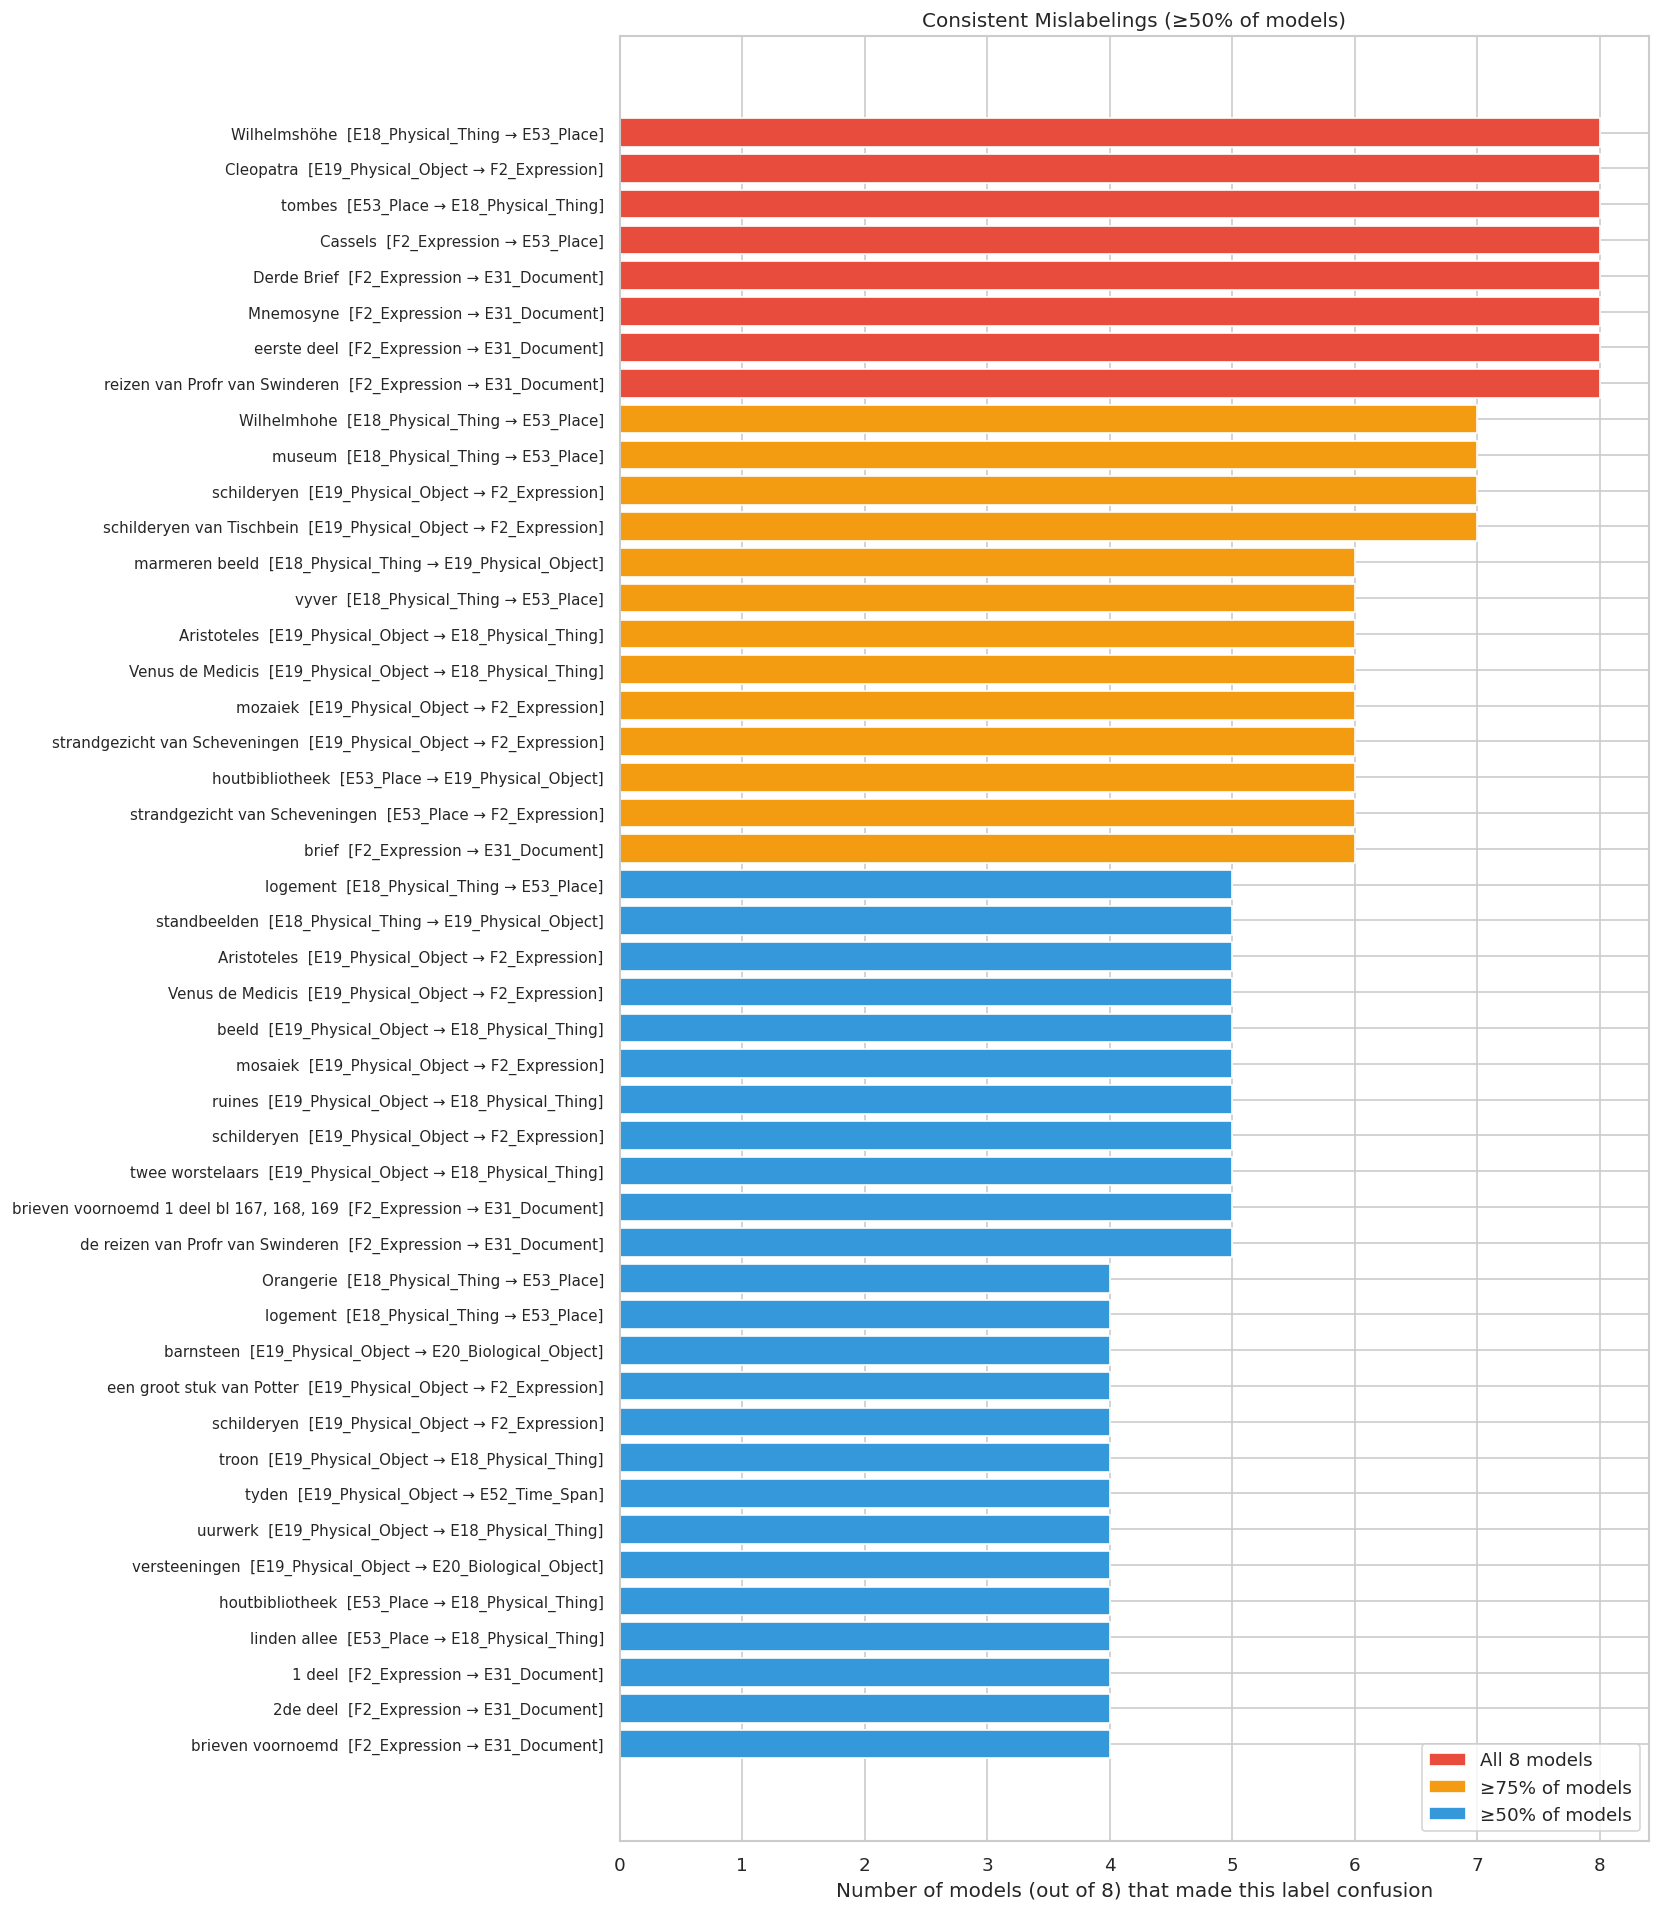

In [44]:
# ── Per-entity breakdown: entities mislabeled by ≥50% of models ──────────
# Show each entity's most common wrong label.

top_mislabels = mislabel_consensus[
    mislabel_consensus["n_models"] >= total_models // 2
].copy()

if len(top_mislabels) > 0:
    fig, ax = plt.subplots(figsize=(14, max(6, len(top_mislabels) * 0.35)))
    
    labels_for_plot = (
        top_mislabels["entity_text"]
        + "  [" + top_mislabels["gs_label"]
        + " → " + top_mislabels["pred_label"] + "]"
    )
    
    colors = [
        "#E74C3C" if rate == 1.0 else "#F39C12" if rate >= 0.75 else "#3498DB"
        for rate in top_mislabels["model_rate"]
    ]
    
    ax.barh(range(len(top_mislabels)), top_mislabels["n_models"], color=colors, edgecolor="white")
    ax.set_yticks(range(len(top_mislabels)))
    ax.set_yticklabels(labels_for_plot, fontsize=9)
    ax.set_xlabel(f"Number of models (out of {total_models}) that made this label confusion")
    ax.set_title("Consistent Mislabelings (≥50% of models)")
    ax.invert_yaxis()
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="#E74C3C", label=f"All {total_models} models"),
        Patch(facecolor="#F39C12", label="≥75% of models"),
        Patch(facecolor="#3498DB", label="≥50% of models"),
    ]
    ax.legend(handles=legend_elements, loc="lower right")
    plt.tight_layout()
    plt.show()
else:
    print("No mislabelings found at ≥50% threshold.")

### Summary: Key label ambiguities for fewshot examples

The patterns above show where models **systematically disagree** with the
ground truth. These are prime candidates for fewshot examples that clarify
the boundary between confusable labels.